In [435]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch

from torch import FloatTensor
from category_encoders import CountEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.neural_network import MLPClassifier

np.seterr(divide='ignore',invalid='ignore',over='ignore')

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

### 1. Data preprocessing

In [436]:
data = pd.read_csv('../datasets/training.csv')
data.PurchDate = pd.to_datetime(data['PurchDate'])
data.sort_values(by='PurchDate',ascending=True,inplace=True)

In [437]:
data = data.sort_values('PurchDate').reset_index(drop=True)

num = len(data)//3
X_train = data.iloc[:num].copy()
X_val   = data.iloc[num:2*num].copy()
X_test  = data.iloc[2*num:].copy()

In [438]:
X_train = X_train.drop(columns=['PRIMEUNIT','AUCGUART'],axis=1)
X_val = X_val.drop(columns=['PRIMEUNIT','AUCGUART'],axis=1)
X_test = X_test.drop(columns=['PRIMEUNIT','AUCGUART'],axis=1)

def extract_date_features(df):
    df = df.copy()
    df['day'] = df['PurchDate'].dt.day
    df['month'] = df['PurchDate'].dt.month
    df = df.drop('PurchDate', axis=1)
    return df

X_train_object = extract_date_features(X_train)
X_val_object = extract_date_features(X_val)
X_test_object = extract_date_features(X_test)

object_columns = []

for column in X_train.columns:
    if ((X_train[column].dtypes))=='object':
        object_columns.append(column)

object_columns

['Auction',
 'Make',
 'Model',
 'Trim',
 'SubModel',
 'Color',
 'Transmission',
 'WheelType',
 'Nationality',
 'Size',
 'TopThreeAmericanName',
 'VNST']

In [439]:
encoder = CountEncoder(cols=object_columns,handle_missing='value')
encoder.fit(X_train_object)

X_train_enc = encoder.transform(X_train_object)
X_val_enc = encoder.transform(X_val_object)
X_test_enc = encoder.transform(X_test_object)

#train_mean = X_train_enc.mean()
X_train_enc = X_train_enc.fillna(0)
X_val_enc = X_val_enc.fillna(0)
X_test_enc = X_test_enc.fillna(0)

y_train = X_train_enc['IsBadBuy'].reset_index(drop=True)
X_train_enc.drop('IsBadBuy',axis=1,inplace=True)
y_val = X_val_enc['IsBadBuy'].reset_index(drop=True)
X_val_enc.drop('IsBadBuy',axis=1,inplace=True)
y_test = X_test_enc['IsBadBuy'].reset_index(drop=True)
X_test_enc.drop('IsBadBuy',axis=1,inplace=True)

In [440]:
scaler = StandardScaler()
scaler.fit(X_train_enc)

X_train = scaler.transform(X_train_enc)
X_val = scaler.transform(X_val_enc)
X_test = scaler.transform(X_test_enc)

X_train = scaler.transform(X_train_enc)

X_train = pd.DataFrame(X_train,columns=list(X_train_enc.columns))
X_val = pd.DataFrame(X_val,columns=list(X_train_enc.columns))
X_test = pd.DataFrame(X_test,columns=list(X_train_enc.columns))

#### functions

In [441]:
gini_results_list = []

def gini_score(y_true, y_pred):
    auc_score = roc_auc_score(y_true, y_pred)
    gini = 2 * auc_score - 1
    return gini

In [442]:
def train_plot_loss_log(model, X_train, y_train, X_val, y_val, n_epochs=100):
    train_losses, val_losses = [], []

    for epoch in range(n_epochs):
        model.fit_one_epoch(X_train, y_train)

        train_loss = model.compute_loss(X_train, y_train)
        val_loss   = model.compute_loss(X_val, y_val)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    plt.figure(figsize=(7,5))
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    

    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()

In [443]:
metrics_df = pd.DataFrame()

def check_metrics(model,X_train,y_train,X_val,y_val, X_test, y_test, metrics_df,name):
    predict_train = model.predict_proba(X_train)[:,1]
    predict_val = model.predict_proba(X_val)[:,1]
    predict_test = model.predict_proba(X_test)[:,1]

    gini_train = gini_score(y_train, predict_train)
    gini_val = gini_score(y_val, predict_val)
    gini_test = gini_score(y_test, predict_test)
    
    row = pd.DataFrame(
        {
            "name_model" : [name],
            "gini_train": [gini_train],
            "gini_val" : [gini_val],
            "gini_test" : [gini_test]
        }
    )

    return pd.concat([metrics_df, row], axis=0, ignore_index=True)

In [463]:
def torch_check_metrics(model, X_train, y_train, X_val, y_val, X_test, y_test, metrics_df, name):

    @torch.no_grad()
    def eval_model(model, X):
        model.eval()

        X = torch.tensor(np.array(X), dtype=torch.float32)
        proba = model(X)
        proba = proba.detach().numpy()

        return proba
    
    predict_train = eval_model(model, X_train)[:,1]
    predict_val = eval_model(model, X_val)[:,1]
    predict_test = eval_model(model, X_test)[:,1]

    gini_train = gini_score(y_train, predict_train)
    gini_val = gini_score(y_val, predict_val)
    gini_test = gini_score(y_test, predict_test)

    row = pd.DataFrame(
        {
            "name_model" : [name],
            "gini_train": [gini_train],
            "gini_val" : [gini_val],
            "gini_test" : [gini_test]
        }
    )

    return pd.concat([metrics_df, row], axis=0, ignore_index=True)

In [ ]:
def train_mlp(model, X, y, criterion, optimizer, n_epoch):
    X = torch.tensor(np.array(X), dtype=torch.float32)
    y = torch.tensor(np.array(y), dtype=torch.float32).view(-1, 1)

    model.train()
    for _ in range(n_epoch):
        optimizer.zero_grad()
        proba = model(X)
        loss = criterion(proba[:,1].view(-1,1), y)
        loss.backward()
        optimizer.step()

    return model

### 2. MLP from Scratch

Внедрите собственную реализацию полносвязной нейронной сети, попробуйте использовать SGD и Adam оптимизации

![Computer](images/photo_ctructure.jpg "")

#### Adam optimizer
Экспонициальные скользящие средние
$$ m = \gamma m + (1-\gamma)∇L_i(w^t) $$
$$ \nu = \alpha \nu + (1-\alpha)∇L_i(w^t) ∇L_i^2(w^t) $$
Некоторая нормировка, позволяющая на первых итерациях работы алгоритма "усилить" наши коээфициенты $ \nu ,G $:
$$ m_{norm} = \frac{m}{1-\gamma^{t+1}} $$
$$ \nu_{norm} = \frac{\nu}{1-\alpha^{t+1}} $$
В конце концов получается:
$$ w_{t+1} = w_t - \eta \frac{m_{norm}}{\sqrt{\nu_{norm}} + \epsilon} $$
В нашем случае $ \alpha,\gamma,\epsilon $ - какие-то константы, можно сказать, что они гиперпараметры

In [ ]:
class myMLP:
    def __init__(self, n_hidden = 32, batch_size = 32, activation = 'relu', optimizer = 'sgd', lr = None, n_epoch = 50, random_state = 21):
        self.n_hidden = n_hidden
        self.batch_size = batch_size
        self.activation = activation
        self.optimizer = optimizer
        if lr is None:
            self.lr = 0.001 if optimizer == 'adam' else 0.1
        else:
            self.lr = lr
        self.n_epoch = n_epoch
        self.random_state = random_state
        self.alpha = 0.05 #for leaky_relu

    def fit(self,X,y):
        for _ in range(self.n_epoch):
            self.fit_one_epoch(X,y)

        return self

    def fit_one_epoch(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.int32)
        n_samples, n_features = X.shape

        if not hasattr(self, "weights_fc1"):
            self.initialize_weights(n_features)

        for X_batch, y_batch in (self._batch_generator(X,y)):
            proba = self.forward_(X_batch)
            grads = self.backward_(X_batch, proba, y_batch)

            if self.optimizer == 'sgd':
                self.sgd_update_weights(*grads)
            else:
                self.adam_update_weights(*grads)
        
        return self
    
    def predict_proba(self, X):
        X = np.asarray(X)
        proba = self.forward_(X)
        return proba

    def predict(self, X):
        X = np.asarray(X)
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)

    def forward_(self, X):
        self.fc1 = X @ self.weights_fc1 + self.bias_fc1

        if self.activation == "relu":
            self.act1_out = self._relu(self.fc1)
        elif self.activation == "sigmoid":
            self.act1_out = self._sigmoid(self.fc1)
        elif self.activation == "cosine":
            self.act1_out = self._cosine(self.fc1)
        elif self.activation == "leaky_relu":
            self.act1_out = self._leaky_relu(self.fc1)
        else:
            self.act1_out = self._tanh(self.fc1)

        # (n_samples, n_features) @ (n_features, 1) + (n_features,)
        self.fc2 = self.act1_out @ self.weights_fc2 + self.bias_fc2
        p1 = self._sigmoid(self.fc2)

        p0 = 1 - p1
        proba = np.hstack([p0, p1])

        return proba
    
    def backward_(self, X, proba, y):
        p1 = proba[:, 1:2]
        dloss_dp = p1 - y.reshape(-1, 1)

        dl_dweights2 = (self.act1_out.T @ dloss_dp) / (int(X.shape[0]))

        dl_dbias2 = dloss_dp.sum(axis=0) / (int(X.shape[0]))
        dl_dact1 = dloss_dp @ self.weights_fc2.T

        if self.activation == 'leaky_relu':
            mask = np.where(self.fc1 > 0, 1.0, self.alpha)
            dl_dfc1 = dl_dact1 * mask
        elif self.activation == 'sigmoid':
            dl_dfc1 = dl_dact1 * self.act1_out * (1 - self.act1_out)
        elif self.activation == 'cosine':
            dl_dfc1 = dl_dact1 * (-np.sin(self.fc1))
        elif self.activation == 'relu':
            mask = (self.fc1 > 0).astype(float)
            dl_dfc1 = dl_dact1 * mask    
        else:
            dl_dfc1 = dl_dact1 * (1-(self._tanh(self.fc1))**2) # tanh

        dl_dweights1 = (X.T @ dl_dfc1) / (int(X.shape[0]))
        dl_dbias1 = dl_dfc1.sum(axis=0) / (int(X.shape[0]))

        return dl_dweights1, dl_dbias1, dl_dweights2, dl_dbias2
    
    def initialize_weights(self, n_features):
        np.random.seed(self.random_state)
        # he-initialization
        if self.activation == 'relu' or self.activation == 'leaky_relu':
            scale1 = np.sqrt(2 / n_features)
        else:
            scale1 = np.sqrt(1 / n_features)
        
        self.weights_fc1 = np.random.normal(0, scale1, (n_features, self.n_hidden))
        self.bias_fc1 = np.zeros(self.n_hidden)

        if self.activation == 'relu' or self.activation == 'leaky_relu':
            scale2 = np.sqrt(2 / self.n_hidden)
        else:
            scale2 = np.sqrt(1 / self.n_hidden)

        self.weights_fc2 = np.random.normal(0, scale2, (self.n_hidden, 1))
        self.bias_fc2 = np.zeros(1)
        
        if self.optimizer == 'adam':
            self.t = 0
            self.moment_fc1_w = np.zeros((n_features, self.n_hidden), dtype=float)  # и есть так называемай моментум
            self.nu_fc1_w = np.zeros((n_features, self.n_hidden), dtype=float)
            self.moment_fc1_b = np.zeros(self.n_hidden)
            self.nu_fc1_b = np.zeros(self.n_hidden)

            self.moment_fc2_w = np.zeros(((self.n_hidden, 1)), dtype=float)
            self.nu_fc2_w = np.zeros(((self.n_hidden, 1)), dtype=float)
            self.moment_fc2_b = np.zeros(1)
            self.nu_fc2_b = np.zeros(1)

    def sgd_update_weights(self, dl_dweights1, dl_dbias1, dl_dweights2, dl_dbias2):
        self.weights_fc1 -= self.lr * dl_dweights1
        self.weights_fc2 -= self.lr * dl_dweights2
        self.bias_fc1 -= self.lr * dl_dbias1
        self.bias_fc2 -= self.lr * dl_dbias2

    def adam_update_weights(self, dl_dweights1, dl_dbias1, dl_dweights2, dl_dbias2):
        self.t += 1
        
        self.update_moments(self.weights_fc1, self.moment_fc1_w, self.nu_fc1_w, dl_dweights1, t=self.t)
        self.update_moments(self.bias_fc1, self.moment_fc1_b, self.nu_fc1_b, dl_dbias1, t=self.t)

        self.update_moments(self.weights_fc2, self.moment_fc2_w, self.nu_fc2_w, dl_dweights2, t=self.t)
        self.update_moments(self.bias_fc2, self.moment_fc2_b, self.nu_fc2_b, dl_dbias2, t=self.t)


    def update_moments(self, old_weights, moment, v, grad, t):
        beta1 = 0.9
        beta2 = 0.999
        eps = 1e-8

        moment[:] = beta1 * moment + (1 - beta1) * grad #[:] - модификация массива на месте
        v[:] = beta2 * v + (1 - beta2) * (grad * grad)

        m_norm = moment / (1 - beta1 ** t)
        v_norm = v / (1 - beta2 ** t)

        old_weights -= self.lr * m_norm / (np.sqrt(v_norm) + eps)
        
    def _sigmoid(self,input):
        input = np.clip(input, -50, 50)
        return 1.0 / (1.0 + np.exp(-input))
    
    def _tanh(self,input):
        return np.tanh(input)
    
    def _cosine(self,input):
        return np.cos(input)
    
    def _relu(self,input):
        return np.maximum(0.0, input)
    
    def _leaky_relu(self,input):
        return np.where(input > 0, input, self.alpha * input)

    def _batch_generator(self, X, y):
        n_samples = X.shape[0]
        indices = np.arange(n_samples)

        np.random.shuffle(indices)

        X_shuffl = X[indices]
        y_shuffl = y[indices]

        for start_idx in range(0, n_samples, self.batch_size):
            end_idx = min(start_idx + self.batch_size, n_samples)
            batch_X = X_shuffl[start_idx:end_idx]
            batch_y = y_shuffl[start_idx:end_idx]
            
            yield batch_X, batch_y
        
    def loss(self, y_true, prob):
        eps = 1e-8
        p1 = prob[:, 1]
        p1 = np.clip(p1, eps, 1 - eps)
        logloss = -np.mean(y_true * np.log(p1) + (1 - y_true) * np.log(1 - p1))
        return logloss
    
    def compute_loss(self, X, y):
        proba = self.predict_proba(X)
        return self.loss(y, proba)


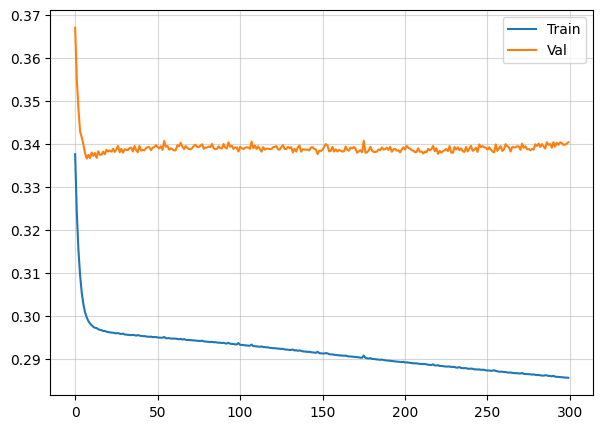

In [ ]:
model = myMLP(optimizer='sgd', activation='sigmoid', lr=0.01, n_epoch=1)
train_plot_loss_log(model,X_train,y_train,X_val,y_val, n_epochs=300)

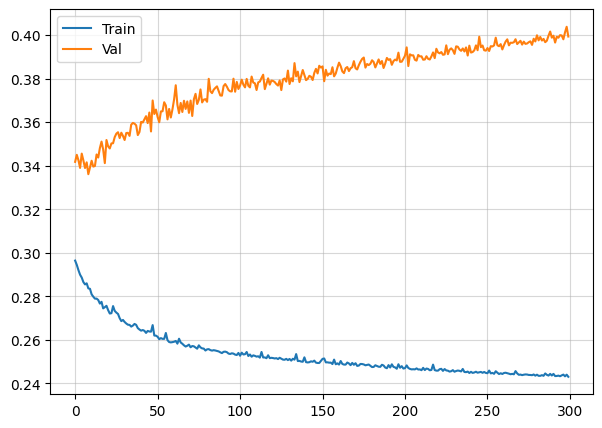

In [ ]:
model = myMLP(optimizer='adam', activation='signoid', lr=1e-3, n_epoch=1)
train_plot_loss_log(model,X_train,y_train,X_val,y_val, n_epochs=300)

Я поэкспериментировал с разными learning_rate и выходами и получил следующие результаты:
- Для оптимизации путем sgd метрика gini получается больше всех на выходах sigmoid и relu \
Если мы используем relu, то наша модель переобучатся больше относительно sigmoid.
- Для оптимизации путем adam метрика gini получается лучше всего на выходе relu, но, к сожалению, ее очень легко переобучить

In [ ]:
model = myMLP(optimizer='sgd', activation='sigmoid', lr=0.05, n_epoch=100)
model.fit(X_train, y_train)
metrics_df = check_metrics(model, X_train, y_train, X_val,y_val, X_test, y_test,metrics_df,'myMLP (sgd + sigmoid)')

In [ ]:
model = myMLP(optimizer='adam', activation='relu', lr=0.0001, n_epoch=100)
model.fit(X_train, y_train)
metrics_df = check_metrics(model, X_train, y_train, X_val,y_val,X_test, y_test,metrics_df,'myMLP (adam + relu)')

In [449]:
metrics_df

,name_model,gini_train,gini_val,gini_test
0,myMLP (sgd + sigmoid),0.562125,0.459163,0.487486
1,myMLP (adam + relu),0.574633,0.454610,0.441391


### 3. Comparison with sklearn

In [ ]:
model = MLPClassifier(solver='sgd',activation='logistic', hidden_layer_sizes=(32,), learning_rate_init=0.05,batch_size=32,random_state=21,max_iter=100)
model.fit(X_train,y_train)
metrics_df = check_metrics(model, X_train, y_train, X_val, y_val, X_test, y_test, metrics_df, f'skMLP (sgd + sigmdoid)')

In [ ]:
model = MLPClassifier(solver='adam',activation='relu', hidden_layer_sizes=(32,), learning_rate_init=0.0001, batch_size=32,random_state=21,max_iter=100)
model.fit(X_train,y_train)
metrics_df = check_metrics(model, X_train, y_train, X_val, y_val,X_test, y_test, metrics_df, f'skMLP (adam + relu)')

In [452]:
metrics_df

,name_model,gini_train,gini_val,gini_test
0,myMLP (sgd + sigmoid),0.562125,0.459163,0.487486
1,myMLP (adam + relu),0.574633,0.454610,0.441391
2,skMLP (sgd + sigmdoid),0.687040,0.362989,0.410787
3,skMLP (adam + relu),0.578080,0.466836,0.475786


По метрикам, моя модель справляется лучше с переобучением, нежели sklearn-версия.  
Вроде все параметры те же самые, но метрика получилась другая, почему же так?  
На самом деле, sk версия имеет больше скрытых параметров по умолчанию, например momentum, l2, другая инициализация и тд \
Если отключить все эти скрытые параметры, то метрика получится одинаковая, как с моей моделью.  
Еще важно сказать, что справление с переобучением - это не всегда хорошо \
В нашем случае, это показывает, что модель возможно наоборот __недообучилась__ из-за мягкой оптимизации

### 4. Activation Function Experiments

![Computer](images/activation_functions.png "")

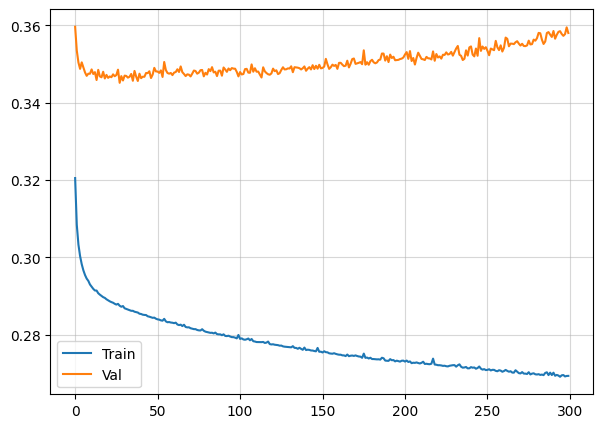

In [ ]:
model = myMLP(optimizer='sgd', activation='relu', lr=0.01, n_epoch=100)
model.fit(X_train, y_train)
metrics_df = check_metrics(model, X_train, y_train, X_val,y_val,X_test, y_test,metrics_df,'myMLP (sgd + relu)')

model = myMLP(optimizer='sgd', activation='relu', lr=0.01, n_epoch=1)
train_plot_loss_log(model,X_train,y_train,X_val,y_val, n_epochs=300)

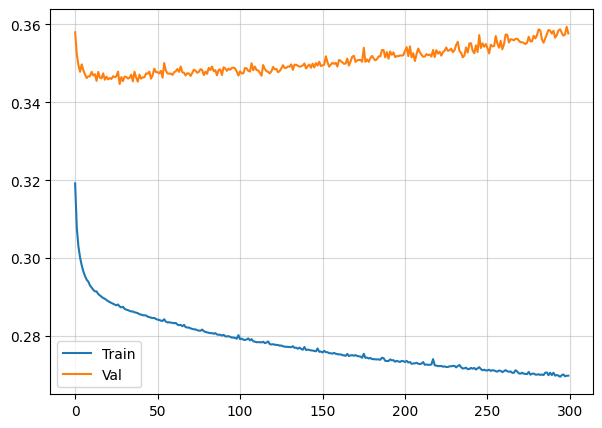

In [ ]:
model = myMLP(optimizer='sgd', activation='leaky_relu', lr=0.01, n_epoch=100)
model.fit(X_train, y_train)
metrics_df = check_metrics(model, X_train, y_train, X_val,y_val,X_test, y_test,metrics_df,'myMLP (sgd + leaky_relu)')

model = myMLP(optimizer='sgd', activation='leaky_relu', lr=0.01, n_epoch=1)
train_plot_loss_log(model,X_train,y_train,X_val,y_val, n_epochs=300)

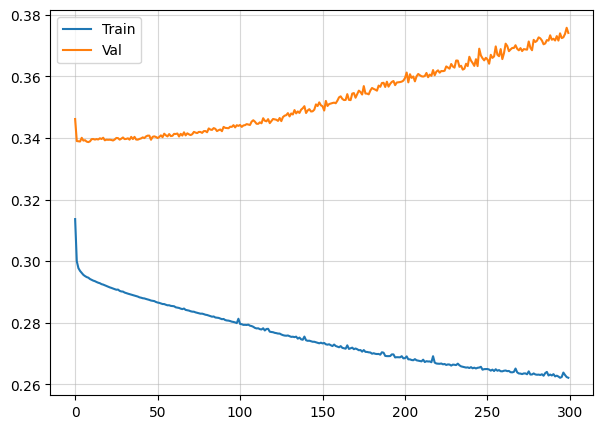

In [ ]:
model = myMLP(optimizer='sgd', activation='tanh', lr=0.01, n_epoch=1)
train_plot_loss_log(model,X_train,y_train,X_val,y_val, n_epochs=300)

model = myMLP(optimizer='sgd', activation='tanh', lr=0.01, n_epoch=100)
model.fit(X_train, y_train)
metrics_df = check_metrics(model, X_train, y_train, X_val,y_val,X_test, y_test,metrics_df,'myMLP (sgd + tanh)')

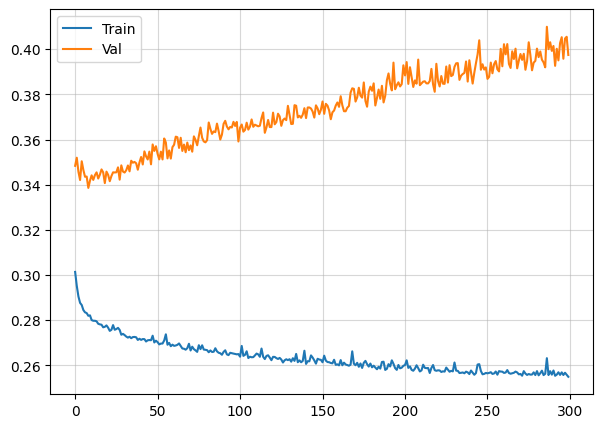

In [ ]:
model = myMLP(optimizer='adam', activation='relu', lr=1e-3, n_epoch=1)
train_plot_loss_log(model,X_train,y_train,X_val,y_val, n_epochs=300)

model = myMLP(optimizer='adam', activation='relu', lr=1e-3, n_epoch=100)
model.fit(X_train, y_train)
metrics_df = check_metrics(model, X_train, y_train, X_val,y_val,X_test, y_test,metrics_df,'myMLP (adam + relu)')

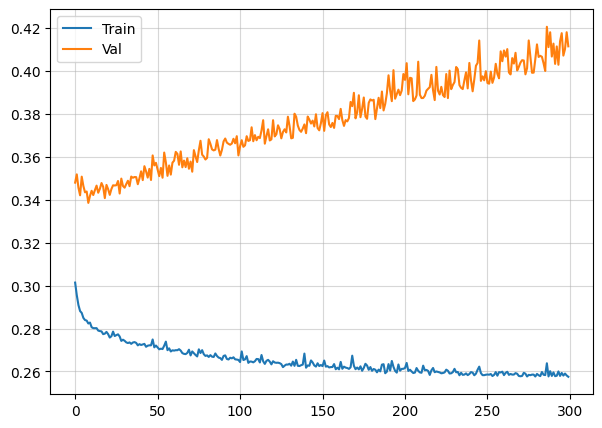

In [ ]:
model = myMLP(optimizer='adam', activation='leaky_relu', lr=1e-3, n_epoch=1)
train_plot_loss_log(model,X_train,y_train,X_val,y_val, n_epochs=300)

model = myMLP(optimizer='adam', activation='leaky_relu', lr=1e-3, n_epoch=100)
model.fit(X_train, y_train)
metrics_df = check_metrics(model, X_train, y_train, X_val,y_val,X_test, y_test,metrics_df,'myMLP (adam + leaky_relu)')

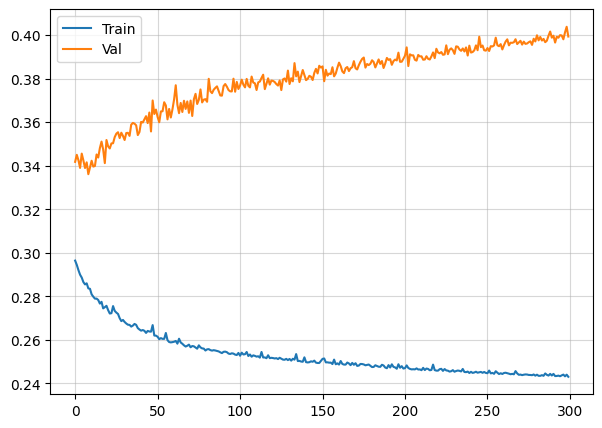

In [ ]:
model = myMLP(optimizer='adam', activation='tanh', lr=1e-3, n_epoch=1)
train_plot_loss_log(model,X_train,y_train,X_val,y_val, n_epochs=300)

model = myMLP(optimizer='adam', activation='tanh', lr=1e-3, n_epoch=100)
model.fit(X_train, y_train)
metrics_df = check_metrics(model, X_train, y_train, X_val,y_val,X_test, y_test,metrics_df,'myMLP (adam + tanh)')

In [459]:
metrics_df

,name_model,gini_train,gini_val,gini_test
0,myMLP (sgd + sigmoid),0.562125,0.459163,0.487486
1,myMLP (adam + relu),0.574633,0.454610,0.441391
2,skMLP (sgd + sigmdoid),0.687040,0.362989,0.410787
3,skMLP (adam + relu),0.578080,0.466836,0.475786
4,myMLP (sgd + relu),0.577526,0.449639,0.445836
5,myMLP (sgd + leaky_relu),0.575768,0.450726,0.448179
6,myMLP (sgd + tanh),0.572091,0.455182,0.463566
7,myMLP (adam + relu),0.642977,0.423778,0.413780
8,myMLP (adam + leaky_relu),0.638370,0.425950,0.417877
9,myMLP (adam + tanh),0.684123,0.399209,0.409127


### 5. PyTorch Implementation

In [ ]:
class Net(nn.Module):
    def __init__(self, n_hidden, n_features):
        super(Net,self).__init__()
        
        self.fc1 = nn.Linear(n_features,n_hidden)
        self.act1 = nn.ReLU()

        self.fc2 = nn.Linear(n_hidden,1)
        self.act2 = nn.Sigmoid()

    def forward(self, X):
        X = self.act1(self.fc1(X))
        p1 = self.act2(self.fc2(X)) 
        p0 = 1 - p1

        return torch.cat([p0,p1],dim=1)

In [462]:
model = Net(n_hidden=32,n_features=X_train.shape[1])
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model = train_mlp(model, X_train, y_train, criterion, optimizer, n_epoch = 300)
torch_check_metrics(model, X_train, y_train, X_val, y_val, X_test, y_test, metrics_df, 'torchNLP (adam + relu)')


,name_model,gini_train,gini_val,gini_test
0,myMLP (sgd + sigmoid),0.562125,0.459163,0.487486
1,myMLP (adam + relu),0.574633,0.454610,0.441391
2,skMLP (sgd + sigmdoid),0.687040,0.362989,0.410787
3,skMLP (adam + relu),0.578080,0.466836,0.475786
4,myMLP (sgd + relu),0.577526,0.449639,0.445836
5,myMLP (sgd + leaky_relu),0.575768,0.450726,0.448179
6,myMLP (sgd + tanh),0.572091,0.455182,0.463566
7,myMLP (adam + relu),0.642977,0.423778,0.413780
8,myMLP (adam + leaky_relu),0.638370,0.425950,0.417877
9,myMLP (adam + tanh),0.684123,0.399209,0.409127


### 6. Best Model and Conclusions

About best model \
Наверное более приятную модельку можно выделить skMLP (adam + relu):
__0.578080__	__0.466836__	__0.475786__ \
Модель имеет относительно неплохие метрики на валидационной/тестовой выборках, причем практически не переобучается, в отличие от остальных.  
Думаю, что, взяв эту модель, можно было через оптуну прогнать гиперпараметры и получить более приятные результаты. 

Также можно выделить модель torchMLP(adam + relu), метрики конечно у нее хуже, но она более стабильная, разница между метриками трейн и тестовой выборкой относительно минимальные. Возможно, модель можно было улучшить через поиск гиперпараметров и получить более лучшие результаты